## Étape 1: Charger et observer le dataset

In [18]:
# Importer les bibliothèques pour la manipulation des données et le machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Charger le fichier CSV du dataset d'entraînement
# Le fichier est maintenant dans le répertoire '/content/data/'
try:
    df_train = pd.read_csv('/content/data/dechets_train_etudiants.csv')
    print("Dataset chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'dechets_train_etudiants.csv' est introuvable. Veuillez vous assurer qu'il est téléchargé dans votre environnement Colab.")
    # Créer un DataFrame vide pour éviter une erreur dans les étapes suivantes si le fichier n'est pas trouvé
    df_train = pd.DataFrame()

Dataset chargé avec succès.


### Observer les premières lignes du dataset

In [9]:
# Afficher les 5 premières lignes du DataFrame pour avoir un aperçu des données
if not df_train.empty:
    display(df_train.head())

,id,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness_mean,saturation_mean,hue_mean,...,texture_lbp,hog_mean,hog_std,circularity,aspect_ratio,compactness,area_norm,color_entropy,contrast,classe
0,IMG_0512,92.26,64.48,105.49,72.12,67.31,65.57,102.17,0.248,70.97,...,0.527,0.521,0.437,0.462,1.099,0.576,0.166,6.353,0.191,autre
1,IMG_0579,45.07,98.53,80.71,61.53,49.03,30.28,165.92,0.696,151.49,...,0.510,0.329,0.322,0.613,0.866,0.477,0.421,7.545,0.446,plastique
2,IMG_0565,114.22,122.44,142.58,73.56,49.64,54.25,53.95,0.536,193.97,...,0.480,0.574,0.198,0.694,0.816,0.547,0.620,4.268,0.399,autre
3,IMG_0039,143.14,92.00,99.93,71.27,43.22,58.83,115.61,0.526,109.92,...,0.775,0.223,0.099,0.524,0.949,0.511,0.025,6.686,0.889,autre
4,IMG_0508,121.79,81.28,126.27,36.51,69.29,34.31,169.20,0.420,160.33,...,0.568,0.393,0.331,0.760,1.288,0.630,0.225,5.327,0.255,verre


### Vérifier les informations générales du dataset

In [10]:
# Afficher un résumé des informations du DataFrame, y compris les types de données, les valeurs non nulles, etc.
if not df_train.empty:
    df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               720 non-null    object 
 1   mean_R           720 non-null    float64
 2   mean_G           720 non-null    float64
 3   mean_B           720 non-null    float64
 4   std_R            720 non-null    float64
 5   std_G            720 non-null    float64
 6   std_B            720 non-null    float64
 7   brightness_mean  720 non-null    float64
 8   saturation_mean  720 non-null    float64
 9   hue_mean         720 non-null    float64
 10  edge_density     720 non-null    float64
 11  texture_lbp      720 non-null    float64
 12  hog_mean         720 non-null    float64
 13  hog_std          720 non-null    float64
 14  circularity      720 non-null    float64
 15  aspect_ratio     720 non-null    float64
 16  compactness      720 non-null    float64
 17  area_norm       

### Visualisation de la distribution des classes

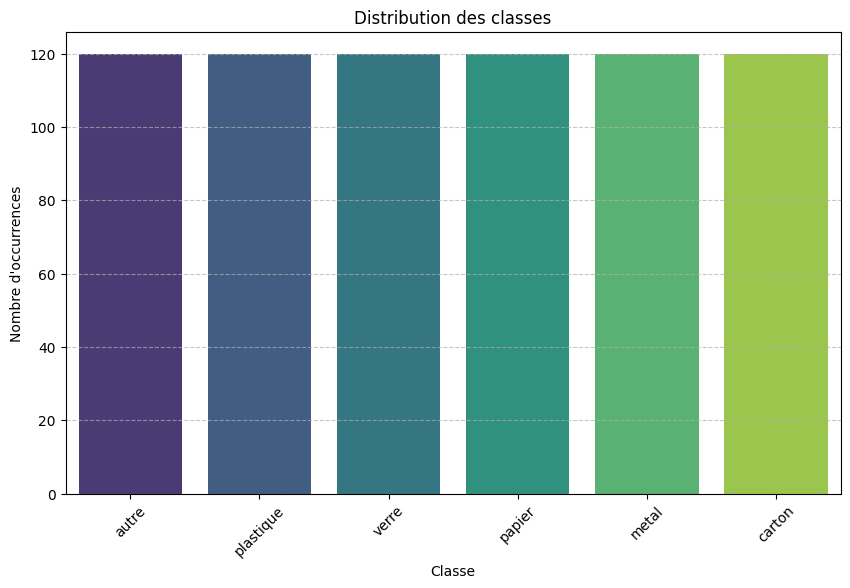

In [19]:
# Vérifier si le DataFrame n'est pas vide et si la colonne 'classe' existe
if not df_train.empty and 'classe' in df_train.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='classe', data=df_train, palette='viridis',hue='classe')
    plt.title('Distribution des classes')
    plt.xlabel('Classe')
    plt.ylabel('Nombre d\'occurrences')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Le DataFrame est vide ou la colonne 'classe' n'existe pas, impossible de créer le graphique.")

## Étape 2: Préparer les données

### Étape 2.1: Séparation des caractéristiques et de la cible

In [20]:
# Séparer les caractéristiques (X qui contient que les caratéristiques sans la valeur cible et l id ) de la variable cible (y)
# La colonne 'id' est un identifiant et n'est pas utile pour l'entraînement du modèle, donc nous la retirons.
X = df_train.drop(columns=['id', 'classe'])
y = df_train['classe'] ## la cible c'est la colonne classe
print("Caractéristiques (X) et cible (y) séparées avec succès.")
print(f"Dimensions de X: {X.shape}")
print(f"Dimensions de y: {y.shape}")

Caractéristiques (X) et cible (y) séparées avec succès.
Dimensions de X: (720, 19)
Dimensions de y: (720,)


### Étape 2.2: Encodage de la variable cible ( qui est une classe catégorielle en valeurs numérique)

In [21]:
# Encoder la variable cible 'classe' qui est catégorielle en valeurs numériques
#on a ajouter 6 colonnes chaque colonne représente une classe avec un valeur
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Variable cible 'classe' encodée avec succès en valeurs numériques.")
print("Classes originales et leurs encodages:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")

Variable cible 'classe' encodée avec succès en valeurs numériques.
Classes originales et leurs encodages:
autre: 0
carton: 1
metal: 2
papier: 3
plastique: 4
verre: 5


### Étape 2.3: Division des données en ensembles d'entraînement et de test

In [22]:
# Diviser les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
# random_state assure la reproductibilité de la division
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded) ##stratify sert à equilibrer les classes entre eux pour avoir le meme nombre de valeurs entre eux
print("Données divisées en ensembles d'entraînement et de test avec succès.")
print(f"Dimensions de X_train: {X_train.shape}")
print(f"Dimensions de X_test: {X_test.shape}")
print(f"Dimensions de y_train: {y_train.shape}")
print(f"Dimensions de y_test: {y_test.shape}")

Données divisées en ensembles d'entraînement et de test avec succès.
Dimensions de X_train: (576, 19)
Dimensions de X_test: (144, 19)
Dimensions de y_train: (576,)
Dimensions de y_test: (144,)


## Étape 3: Tester plusieurs modèles

### Modèle 1: Régression Logistique

In [23]:
print("Entraînement du modèle de Régression Logistique...")

# Initialiser le modèle de Régression Logistique
# max_iter augmenté pour assurer la convergence
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Entraîner le modèle sur les données d'entraînement
logistic_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_logistic = logistic_model.predict(X_test)

# Calculer la précision (accuracy)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"Précision du modèle de Régression Logistique: {accuracy_logistic:.4f}")

Entraînement du modèle de Régression Logistique...
Précision du modèle de Régression Logistique: 0.7569


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Modèle 2: Forêt Aléatoire (Random Forest)

In [24]:
print("Entraînement du modèle de Forêt Aléatoire...")

# Initialiser le modèle de Forêt Aléatoire
# n_estimators est le nombre d'arbres dans la forêt
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle sur les données d'entraînement
random_forest_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_rf = random_forest_model.predict(X_test)

# Calculer la précision (accuracy)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Précision du modèle de Forêt Aléatoire: {accuracy_rf:.4f}")

Entraînement du modèle de Forêt Aléatoire...
Précision du modèle de Forêt Aléatoire: 0.8333


### Modèle 3: K-Nearest Neighbors (KNN)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

print("Entraînement du modèle K-Nearest Neighbors...")

# Initialiser le modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors est le nombre de voisins à considérer

# Entraîner le modèle sur les données d'entraînement
knn_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_knn = knn_model.predict(X_test)

# Calculer la précision (accuracy)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Précision du modèle K-Nearest Neighbors: {accuracy_knn:.4f}")

Entraînement du modèle K-Nearest Neighbors...
Précision du modèle K-Nearest Neighbors: 0.7222


### Modèle 4: Support Vector Machine (SVM)

In [41]:
from sklearn.svm import SVC

print("Entraînement du modèle Support Vector Machine...")

# Initialiser le modèle SVM
# Un noyau linéaire est un bon point de départ pour la plupart des problèmes
svm_model = SVC(kernel='linear', random_state=42)

# Entraîner le modèle sur les données d'entraînement
svm_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_svm = svm_model.predict(X_test)

# Calculer la précision (accuracy)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Précision du modèle Support Vector Machine: {accuracy_svm:.4f}")

Entraînement du modèle Support Vector Machine...
Précision du modèle Support Vector Machine: 0.8125


## Étape 4: Calculer les métriques

### Métriques pour le modèle de Régression Logistique

Rapport de classification pour la Régression Logistique:
              precision    recall  f1-score   support

       autre       0.61      0.71      0.65        24
      carton       0.88      0.96      0.92        24
       metal       0.86      0.79      0.83        24
      papier       1.00      1.00      1.00        24
   plastique       0.52      0.50      0.51        24
       verre       0.67      0.58      0.62        24

    accuracy                           0.76       144
   macro avg       0.76      0.76      0.76       144
weighted avg       0.76      0.76      0.76       144

Matrice de confusion pour la Régression Logistique:


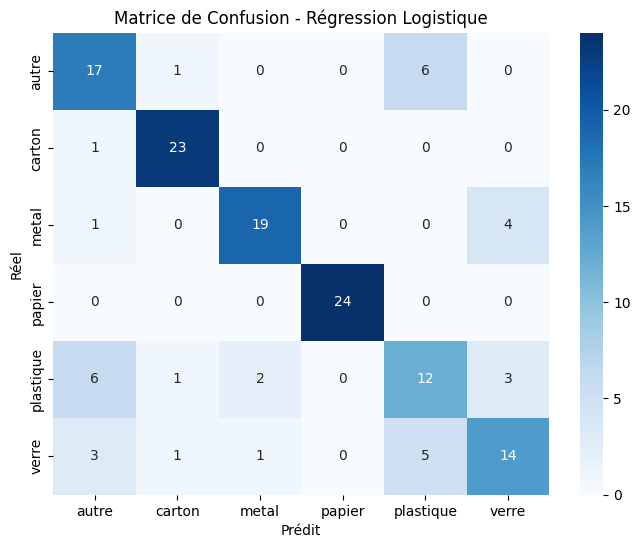

In [42]:
print("Rapport de classification pour la Régression Logistique:")
print(classification_report(y_test, y_pred_logistic, target_names=label_encoder.classes_))

print("Matrice de confusion pour la Régression Logistique:")
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Régression Logistique')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

### Métriques pour le modèle de Forêt Aléatoire (Random Forest)

Rapport de classification pour la Forêt Aléatoire:
              precision    recall  f1-score   support

       autre       0.75      0.62      0.68        24
      carton       0.96      1.00      0.98        24
       metal       0.92      0.96      0.94        24
      papier       1.00      1.00      1.00        24
   plastique       0.58      0.75      0.65        24
       verre       0.84      0.67      0.74        24

    accuracy                           0.83       144
   macro avg       0.84      0.83      0.83       144
weighted avg       0.84      0.83      0.83       144

Matrice de confusion pour la Forêt Aléatoire:


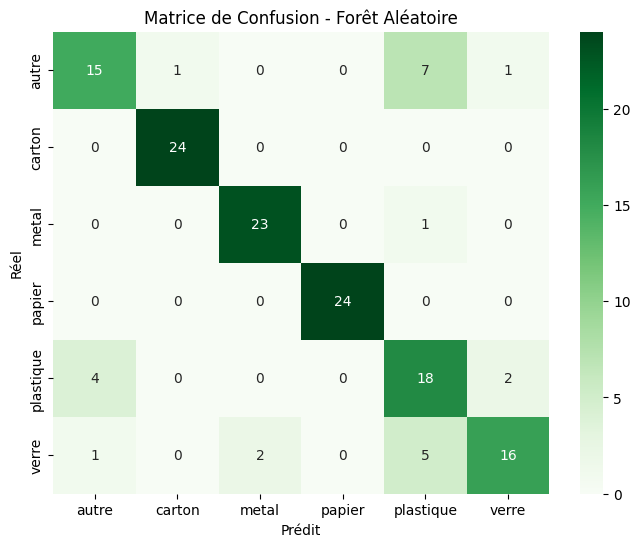

In [27]:
print("Rapport de classification pour la Forêt Aléatoire:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

print("Matrice de confusion pour la Forêt Aléatoire:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Forêt Aléatoire')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

### Métriques pour le modèle K-Nearest Neighbors (KNN)

Rapport de classification pour le K-Nearest Neighbors:
              precision    recall  f1-score   support

       autre       0.65      0.62      0.64        24
      carton       0.89      1.00      0.94        24
       metal       0.65      0.83      0.73        24
      papier       1.00      1.00      1.00        24
   plastique       0.56      0.42      0.48        24
       verre       0.52      0.46      0.49        24

    accuracy                           0.72       144
   macro avg       0.71      0.72      0.71       144
weighted avg       0.71      0.72      0.71       144

Matrice de confusion pour le K-Nearest Neighbors:


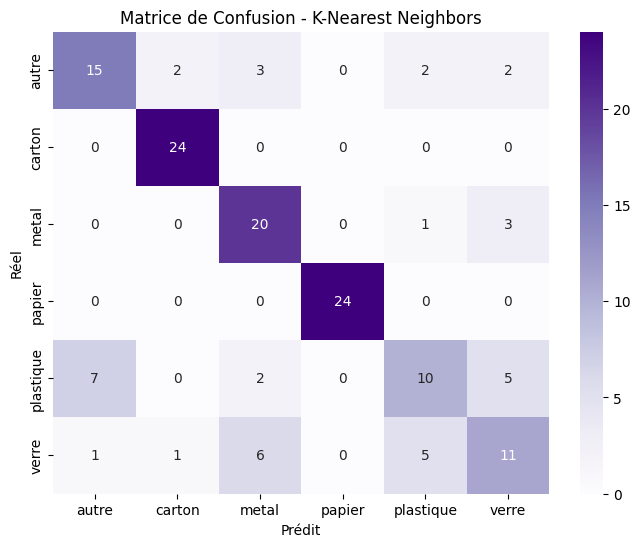

In [28]:
print("Rapport de classification pour le K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

print("Matrice de confusion pour le K-Nearest Neighbors:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - K-Nearest Neighbors')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

### Métriques pour le modèle Support Vector Machine (SVM)

Rapport de classification pour le Support Vector Machine:
              precision    recall  f1-score   support

       autre       0.64      0.67      0.65        24
      carton       0.96      1.00      0.98        24
       metal       0.95      0.88      0.91        24
      papier       1.00      1.00      1.00        24
   plastique       0.57      0.67      0.62        24
       verre       0.80      0.67      0.73        24

    accuracy                           0.81       144
   macro avg       0.82      0.81      0.81       144
weighted avg       0.82      0.81      0.81       144

Matrice de confusion pour le Support Vector Machine:


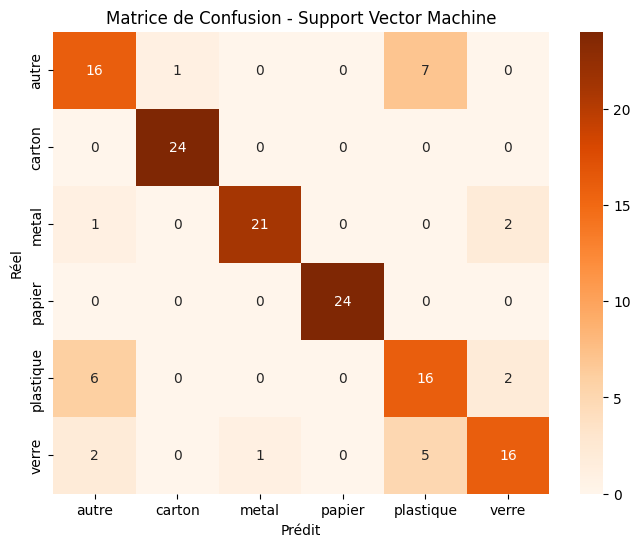

In [43]:
print("Rapport de classification pour le Support Vector Machine:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

print("Matrice de confusion pour le Support Vector Machine:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Support Vector Machine')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

## Étape 5: Choisir le meilleur modèle

In [44]:
print(f"Précision de la Régression Logistique: {accuracy_logistic:.4f}")
print(f"Précision de la Forêt Aléatoire: {accuracy_rf:.4f}")
print(f"Précision du K-Nearest Neighbors: {accuracy_knn:.4f}")

best_model_name = ""
best_model = None
best_accuracy = -1

models = {
    "Régression Logistique": (logistic_model, accuracy_logistic),
    "Forêt Aléatoire": (random_forest_model, accuracy_rf),
    "K-Nearest Neighbors": (knn_model, accuracy_knn)
}

for name, (model, accuracy) in models.items():
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model = model

print(f"\nLe meilleur modèle jusqu'à présent est le **{best_model_name}** avec une précision de **{best_accuracy:.4f}**.")

Précision de la Régression Logistique: 0.7569
Précision de la Forêt Aléatoire: 0.8333
Précision du K-Nearest Neighbors: 0.7222

Le meilleur modèle jusqu'à présent est le **Forêt Aléatoire** avec une précision de **0.8333**.


In [47]:
print(f"Précision de la Régression Logistique: {accuracy_logistic:.4f}")
print(f"Précision de la Forêt Aléatoire: {accuracy_rf:.4f}")
print(f"Précision du K-Nearest Neighbors: {accuracy_knn:.4f}")
print(f"Précision du Support Vector Machine: {accuracy_svm:.4f}")

best_model_name = ""
best_model = None
best_accuracy = -1

models = {
    "Régression Logistique": (logistic_model, accuracy_logistic),
    "Forêt Aléatoire": (random_forest_model, accuracy_rf),
    "K-Nearest Neighbors": (knn_model, accuracy_knn),
    "Support Vector Machine": (svm_model, accuracy_svm)
}

for name, (model, accuracy) in models.items():
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model = model

print(f"\nLe meilleur modèle jusqu'à présent est le **{best_model_name}** avec une précision de **{best_accuracy:.4f}**.")

Précision de la Régression Logistique: 0.7569
Précision de la Forêt Aléatoire: 0.8333
Précision du K-Nearest Neighbors: 0.7222
Précision du Support Vector Machine: 0.8125

Le meilleur modèle jusqu'à présent est le **Forêt Aléatoire** avec une précision de **0.8333**.


# pour le modéle choisit qui est le random forest le metrique pris en considération pour choisir ce  modéle c'est le f1 score qui equilibre entre le rappel et la **précision**

## Étape 6: Prédire avec un fichier de test le meilleur modéle

In [48]:
print("Chargement du dataset de test sans labels...")

# Charger le fichier CSV du dataset de test sans labels
try:
    df_test_nolabels = pd.read_csv('/content/data/dechets_test_sans_labels.csv')
    print("Dataset de test sans labels chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'dechets_test_sans_labels.csv' est introuvable.")
    df_test_nolabels = pd.DataFrame()

# Afficher les 5 premières lignes du DataFrame de test pour vérification
if not df_test_nolabels.empty:
    display(df_test_nolabels.head())
    df_test_nolabels_ids = df_test_nolabels['id'] # Garder les IDs pour le fichier de soumission
    X_test_final = df_test_nolabels.drop(columns=['id']) # Retirer la colonne 'id' pour la prédiction
else:
    X_test_final = pd.DataFrame()

Chargement du dataset de test sans labels...
Dataset de test sans labels chargé avec succès.


,id,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness_mean,saturation_mean,hue_mean,edge_density,texture_lbp,hog_mean,hog_std,circularity,aspect_ratio,compactness,area_norm,color_entropy,contrast
0,IMG_0652,156.95,144.94,119.39,56.34,52.71,59.94,88.56,0.549,27.00,0.290,0.736,0.323,0.235,0.729,0.863,0.476,0.325,5.822,0.554
1,IMG_0037,204.53,229.39,186.11,23.90,20.71,13.83,205.19,0.171,65.68,0.283,0.293,0.234,0.105,0.582,1.946,0.606,0.515,3.720,0.072
2,IMG_0405,32.48,63.03,106.48,69.77,60.79,48.92,71.75,0.575,0.00,0.254,0.504,0.427,0.289,0.575,1.665,0.753,0.536,6.819,0.531
3,IMG_0026,190.19,88.50,232.64,49.65,67.91,49.03,150.75,0.659,19.11,0.194,0.564,0.112,0.446,0.361,1.596,0.293,0.119,5.244,0.517
4,IMG_0410,140.76,90.69,70.62,54.69,74.66,63.21,138.32,0.725,106.59,0.244,0.488,0.179,0.336,0.149,1.392,0.758,0.460,6.693,0.265


In [39]:
if not X_test_final.empty and best_model is not None:
    print(f"Prédictions sur le dataset de test en utilisant le modèle: {best_model_name}...")

    # Faire les prédictions
    final_predictions_encoded = best_model.predict(X_test_final)

    # Convertir les prédictions numériques en labels de classe originaux
    final_predictions_labels = label_encoder.inverse_transform(final_predictions_encoded)

    # Créer un DataFrame pour les résultats
    results_df = pd.DataFrame({
        'id': df_test_nolabels_ids,
        'classe': final_predictions_labels
    })

    print("Prédictions effectuées avec succès. Voici les 5 premières prédictions:")
    display(results_df.head())

    # Optionnel: Sauvegarder les prédictions dans un fichier CSV
    # results_df.to_csv('predictions_dechets.csv', index=False)
    # print("Les prédictions ont été sauvegardées dans 'predictions_dechets.csv'")
else:
    print("Impossible de faire les prédictions. Le dataset de test est vide ou aucun modèle n'a été sélectionné.")

Prédictions sur le dataset de test en utilisant le modèle: Forêt Aléatoire...
Prédictions effectuées avec succès. Voici les 5 premières prédictions:


,id,classe
0,IMG_0652,autre
1,IMG_0037,papier
2,IMG_0405,autre
3,IMG_0026,autre
4,IMG_0410,autre
